Running Production Mark-to-Model Simulation: 100%|██████████| 10000/10000 [00:28<00:00, 355.28it/s]


Analytic EL: £459.74m
Simulated EL: £461.57m
VaR (99%): £809.97m
Expected Shortfall (99%): £924.50m
NOTE: All maturity horizons are modelled to be between 1 and 10 years (uniformly distributed)


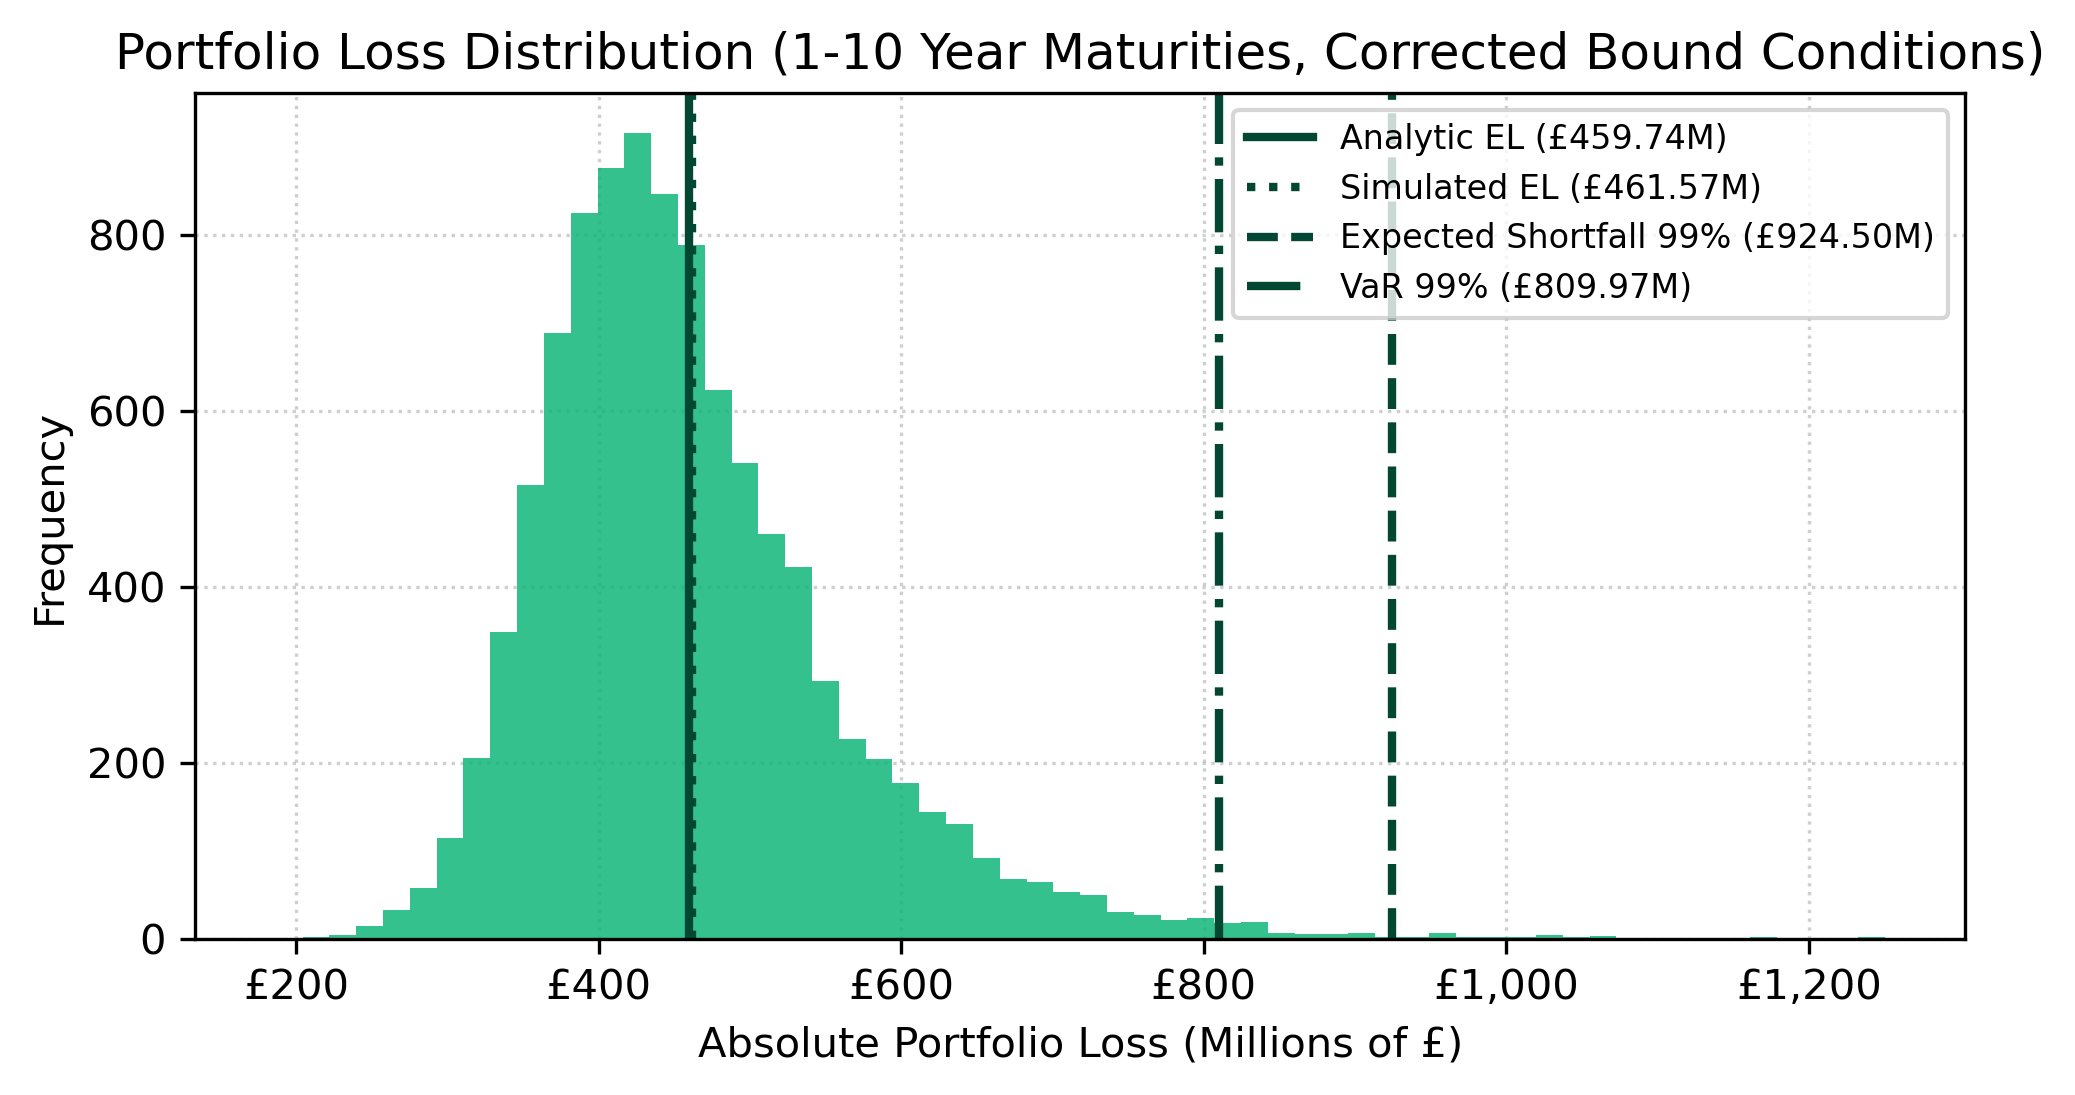

In [1]:
"""
This is the master code for the multistate model. We can feed in any loan book, and the output is a loss distribution for that specific book.
"""

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from tqdm import tqdm

# Corporate color scheme variables
everyday_green = '#11B67A'
racing_green = '#024731'

class MarkToModelPortfolioSimulator:

    def __init__(self):
        self.portfolio_df = None
        self.cov = None
        self.C = None
        self.losses = None
        self.tm_df = None

    def _make_pd(self, cov, eps=1e-8):
        """Ensures the macroeconomic covariance matrix is strictly positive definite."""
        cov = (cov + cov.T) / 2
        lam_min = np.linalg.eigvalsh(cov).min()
        delta = max(0.0, -lam_min + eps)
        return cov + delta * np.eye(cov.shape[0])
    
    def _chol_from_cov(self, cov, eps=1e-8):
        """Generates the Cholesky factor matrix for correlated sector shocks."""
        cov_pd = self._make_pd(cov, eps=eps)
        C = np.linalg.cholesky(cov_pd)
        return cov_pd, C

    def build_lifetime_el_matrix(self, loan_book, pd_mapping, tm_df, seed=42):
        df = loan_book.copy()
        rng = np.random.default_rng(seed)
        
        if 'residual maturity (yrs)' not in df.columns:
            df['residual maturity (yrs)'] = rng.uniform(1.0, 10.0, size=len(df))
            
        if 'pd' not in df.columns:
            left_col = 'credit_rating'
            right_col = 'Credit Rating' if 'Credit Rating' in pd_mapping.columns else 'credit_rating'
            df = pd.merge(df, pd_mapping, left_on=left_col, right_on=right_col, how='left')
            
        ead = df['ead'].to_numpy()
        lgd = df['lgd'].to_numpy()
        t = df['residual maturity (yrs)'].to_numpy()
        cash_risk_factor = ead * lgd
        
        df['0'] = cash_risk_factor
        
        states_non_default_aligned = ['CCC', 'B', 'BB', 'BBB', 'A', 'AA', 'AAA']
        
        for idx, state in enumerate(states_non_default_aligned):
            pd_state = tm_df.loc[state, 'Default']
            
            # Populate columns '1' through '7' with the correctly scaled lifetime loss
            df[str(idx + 1)] = cash_risk_factor * (1.0 - (1.0 - pd_state) ** t)
            
        return df

    def _compute_multi_state_thresholds(self, tm_df, eps=1e-12):
        self.ordered_states = ['Default'] + ['CCC', 'B', 'BB', 'BBB', 'A', 'AA', 'AAA']
        tm_ordered = tm_df[self.ordered_states]
        cum_probs = tm_ordered.cumsum(axis=1)
        cum_probs_clipped = np.clip(cum_probs.to_numpy(), eps, 1.0 - eps)
        thresholds_matrix = norm.ppf(cum_probs_clipped)
        threshold_lookup = {rating: thresholds_matrix[i, :] for i, rating in enumerate(tm_df.index)}
        return threshold_lookup

    def _build_factor_loadings(self, factor_index, M, N, C):
        F = np.zeros((M, N), dtype=float)
        for i, (_, row) in enumerate(self.portfolio_df[['region', 'sector']].iterrows()):
            F[i, factor_index[row['region']]] = 1.0
            F[i, factor_index[row['sector']]] = 1.0

        FC = F @ C
        row_norms = np.linalg.norm(FC, axis=1, keepdims=True)
        return FC / row_norms

    def simulate_losses(
        self,
        loan_book,
        pd_mapping,
        tm_df,
        factor_index,
        cov,
        n_scenarios=10000,
        chunk=1000,
        seed=42
    ):
        """Runs the Production Mark-to-Model Lifetime EL Simulation without stress modifiers."""
        if 'loan_id' in loan_book.iloc[0].values:
            loan_book = loan_book.copy()
            loan_book.columns = loan_book.iloc[0]
            loan_book = loan_book.drop(loan_book.index[0]).reset_index(drop=True)
            
        for col in ['ead', 'lgd', 'rsq', 'PD 1yr', 'residual maturity (yrs)']:
            if col in loan_book.columns:
                loan_book[col] = pd.to_numeric(loan_book[col], errors='coerce')

        enriched_book = self.build_lifetime_el_matrix(loan_book, pd_mapping, tm_df, seed=seed)
        self.portfolio_df = enriched_book.reset_index(drop=True)
        self.cov, self.C = self._chol_from_cov(np.asarray(cov, float))
        self.tm_df = tm_df
        
        M = len(self.portfolio_df)
        N = len(factor_index)

        threshold_lookup = self._compute_multi_state_thresholds(tm_df)
        asset_thresholds = np.array([threshold_lookup[r] for r in self.portfolio_df['credit_rating']])
        
        state_cols = [str(i) for i in range(8)]
        lel_matrix = self.portfolio_df[state_cols].to_numpy()
        
        initial_state_map = {'Default': 0, 'CCC': 1, 'B': 2, 'BB': 3, 'BBB': 4, 'A': 5, 'AA': 6, 'AAA': 7}
        initial_indices = self.portfolio_df['credit_rating'].map(initial_state_map).to_numpy()
        baseline_el = lel_matrix[np.arange(M), initial_indices]
        self._analytic_el_val = float(baseline_el.sum())

        sqrt_rsq = np.sqrt(np.clip(self.portfolio_df['rsq'].to_numpy(), 0.0, 1.0))[:, None]
        FC_hat = self._build_factor_loadings(factor_index, M, N, self.C)
        
        rng = np.random.default_rng(seed)
        losses_out = np.empty(n_scenarios)
        filled = 0

        # Optimizations for stability 
        chunk_losses_master = np.empty((M, chunk), dtype=np.float64)
        
        with tqdm(total=n_scenarios, desc='Running Production Mark-to-Model Simulation') as pbar:
            while filled < n_scenarios:
                s = min(chunk, n_scenarios - filled)
                sl = slice(filled, filled + s)

                # Pure production stochastic sampling
                Z = rng.standard_normal(size=(N, s))
                Y = FC_hat @ Z
                Xi = rng.standard_normal(size=(M, s))
                X = sqrt_rsq * Y + np.sqrt(1.0 - sqrt_rsq ** 2) * Xi 

                chunk_losses = chunk_losses_master[:, :s]
                for asset_idx in range(M):
                    bin_indices = np.digitize(X[asset_idx, :], asset_thresholds[asset_idx, :])
                    bin_indices = np.clip(bin_indices, 0, lel_matrix.shape[1] - 1)
                    chunk_losses[asset_idx, :] = lel_matrix[asset_idx, bin_indices]

                losses_out[sl] = chunk_losses.sum(axis=0)
                filled += s
                pbar.update(s)

        self.losses = pd.Series(losses_out)
        return self.losses

    def analytic_EL(self):
        """
        Calculates the true analytical Expected Loss for the Mark-to-Model framework.
        Since the simulation maps 1-year migration states to pre-calculated lifetime losses,
        the analytical EL is the dot product of the 1-year transition probabilities 
        and their corresponding destination state losses.
        """
        total_analytic_el = 0.0
        
        ordered_states = ['Default', 'CCC', 'B', 'BB', 'BBB', 'A', 'AA', 'AAA']
        tm_ordered = self.tm_df[ordered_states]
        
        state_cols = [str(i) for i in range(8)]
        lel_matrix = self.portfolio_df[state_cols].to_numpy()
        
        for i, row in self.portfolio_df.iterrows():
            current_rating = row['credit_rating']
            
            prob_vector = tm_ordered.loc[current_rating].to_numpy()
            
            asset_losses = lel_matrix[i, :]
            
            total_analytic_el += np.dot(prob_vector, asset_losses)
            
        return total_analytic_el

    def var_quantile(self, alpha=0.99):
        return float(np.quantile(self.losses.to_numpy(), alpha))

    def expected_shortfall(self, alpha=0.99):
        arr = self.losses.to_numpy()
        q = np.quantile(arr, alpha)
        tail = arr[arr >= q]
        return float(tail.mean()) if len(tail) > 0 else float(q)

    def plot_loss_distribution(self):
        """Generates an absolute portfolio loss distribution scaled in Millions of Pounds (£M)."""
        plt.close('all')
        
        arr = self.losses.to_numpy()
        scale = 1_000_000.0

        fig, ax = plt.subplots(figsize=(6.75, 3.75), dpi=300)
        ax.hist(arr / scale, bins=60, color=everyday_green, edgecolor=None, alpha=0.85)

        ax.axvline(self.analytic_EL() / scale, color=racing_green, lw=2, label=f'Analytic EL (£{self.analytic_EL()/scale:,.2f}M)')
        ax.axvline(arr.mean() / scale, color=racing_green, lw=2, ls=':', label=f'Simulated EL (£{arr.mean()/scale:,.2f}M)')
        ax.axvline(self.expected_shortfall(0.99) / scale, color=racing_green, lw=2, ls='--', label=f'Expected Shortfall 99% (£{self.expected_shortfall(0.99)/scale:,.2f}M)')
        ax.axvline(self.var_quantile(0.99) / scale, color=racing_green, lw=2, ls='-.', label=f'VaR 99% (£{self.var_quantile(0.99)/scale:,.2f}M)')

        ax.set_title('Portfolio Loss Distribution (1-10 Year Maturities, Corrected Bound Conditions)')
        ax.set_xlabel('Absolute Portfolio Loss (Millions of £)')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_axisbelow(True)
        ax.xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('£{x:,.0f}'))
        fig.tight_layout()
        return fig


systematic_shocks = pd.read_csv('systematic_shocks.csv', index_col='Quarter')
cov = systematic_shocks.cov()
factors = list(cov.columns)
factor_index = {name: j for j, name in enumerate(factors)}

raw_loan_book = pd.read_csv('loan_book.csv') 
pd_mapping = pd.read_csv('pd_mapping.csv')
tm_df = pd.read_csv('transition_matrix.csv', index_col='From/To')

sim = MarkToModelPortfolioSimulator()
sim.simulate_losses(
    loan_book=raw_loan_book,
    pd_mapping=pd_mapping,
    tm_df=tm_df,
    factor_index=factor_index,
    cov=cov,
    n_scenarios=10000
)

portfolio = sim.portfolio_df

# 3. Print layout tables
print(f"Analytic EL: £{sim.analytic_EL()/1e6:.2f}m")
print(f"Simulated EL: £{sim.losses.mean()/1e6:.2f}m")
print(f"VaR (99%): £{sim.var_quantile(0.99)/1e6:.2f}m")
print(f"Expected Shortfall (99%): £{sim.expected_shortfall(0.99) / 1e6:.2f}m")
print("NOTE: All maturity horizons are modelled to be between 1 and 10 years (uniformly distributed)")

fig = sim.plot_loss_distribution()
fig.savefig('3) MultiState.png', dpi=300)
plt.show()